# Error Analysis: Centroid vs Simplex Models

Compare error patterns between:
- **Centroid model** (exp01 NB09): test 0.9553, silhouette 0.6213
- **Simplex model** (exp02 NB02): test 0.9654, silhouette 0.7623

**Prerequisites:** Run NB09 and NB02 first to generate checkpoints:
- `experimentation/01_centroid_projection/checkpoints/centroid_infer_last.pt`
- `experimentation/02_clustering_pretrain/checkpoints/simplex_classify.pt`

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report

torch.manual_seed(42)
device = torch.device("cpu")
print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/morgancooper/NeuralNetworkProjectionOperator


## 1. Load Data

Same transforms and splits as both training notebooks.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.view(-1)),
])

data_root = os.path.join(PROJECT_ROOT, "data")
full_train_dataset = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=data_root, train=False, download=True, transform=transform)

train_dataset, val_dataset = random_split(
    full_train_dataset, [48000, 12000],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

Train: 48000, Test: 10000


## 2. Define Model Architectures

In [3]:
# --- Centroid Model (from NB09) ---

class CentroidProjection(nn.Module):
    def __init__(self, dim, num_classes=10, alpha=0.1, beta=0.05, infer=False):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.num_classes = num_classes
        self.infer = infer
        self.register_buffer('centroids', torch.zeros(num_classes, dim))
        self.register_buffer('ready', torch.tensor(False))

    def update_centroids(self, centroids):
        self.centroids.copy_(centroids)
        self.ready.fill_(True)

    def forward(self, x, labels=None):
        if not self.ready:
            return x
        if labels is None:
            if not self.infer:
                return x
            with torch.no_grad():
                dists = torch.cdist(x, self.centroids)
                labels = dists.argmin(dim=1)
        with torch.no_grad():
            repulsion = torch.zeros_like(self.centroids)
            for c in range(self.num_classes):
                others = [i for i in range(self.num_classes) if i != c]
                diffs = self.centroids[c] - self.centroids[others]
                dists = diffs.norm(dim=1, keepdim=True).clamp(min=1e-6)
                repulsion[c] = (diffs / dists ** 2).sum(dim=0)
            rep_norms = repulsion.norm(dim=1, keepdim=True).clamp(min=1e-6)
            repulsion = repulsion / rep_norms * self.beta
            nudge = repulsion[labels]
            diff = self.centroids[labels] - x
            dist = diff.norm(dim=1, keepdim=True).clamp(min=1e-6)
            mean_dist = dist.mean()
            scale = dist / (mean_dist + 1e-8)
            nudge = nudge + self.alpha * scale * diff
        return x + nudge


class CentroidMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.ln2 = nn.LayerNorm(64)
        self.drop2 = nn.Dropout(0.3)
        self.proj = CentroidProjection(64, num_classes=10, alpha=0.3, beta=0.1, infer=True)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x, labels=None):
        x = self.drop1(torch.relu(self.bn1(self.fc1(x))))
        x = self.drop2(torch.relu(self.ln2(self.fc2(x))))
        x = self.proj(x, labels)
        x = self.fc3(x)
        return x

    def compute_centroids(self, loader, device):
        self.eval()
        sums = torch.zeros(10, 64, device=device)
        counts = torch.zeros(10, device=device)
        with torch.no_grad():
            for batch_x, batch_y in loader:
                batch_x = batch_x.to(device)
                h = torch.relu(self.ln2(self.fc2(self.drop1(torch.relu(self.bn1(self.fc1(batch_x)))))))
                for c in range(10):
                    mask = (batch_y == c)
                    if mask.any():
                        sums[c] += h[mask].sum(dim=0)
                        counts[c] += mask.sum()
        return sums / counts.unsqueeze(1).clamp(min=1)


# --- Simplex Model (from NB02) ---

class SimplexNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.ln2 = nn.LayerNorm(64)
        self.drop2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.drop1(torch.relu(self.bn1(self.fc1(x))))
        x = self.drop2(torch.relu(self.ln2(self.fc2(x))))
        x = self.fc3(x)
        return x


print("Model classes defined.")

Model classes defined.


## 3. Load Checkpoints

In [4]:
# Load centroid model
centroid_model = CentroidMLP().to(device)
centroid_ckpt = os.path.join(PROJECT_ROOT, "experimentation", "01_centroid_projection", "checkpoints", "centroid_infer_last.pt")
centroid_model.load_state_dict(torch.load(centroid_ckpt, map_location=device, weights_only=True))
centroid_model.eval()

# Compute centroids from training data (needed for inference projection)
centroids = centroid_model.compute_centroids(train_loader, device)
centroid_model.proj.update_centroids(centroids)
print(f"Centroid model loaded from {centroid_ckpt}")
print(f"  Centroids computed from {len(train_loader.dataset)} training samples")

# Load simplex model
simplex_model = SimplexNet().to(device)
simplex_ckpt = os.path.join(PROJECT_ROOT, "experimentation", "02_clustering_pretrain", "checkpoints", "simplex_classify.pt")
simplex_model.load_state_dict(torch.load(simplex_ckpt, map_location=device, weights_only=True))
simplex_model.eval()
print(f"Simplex model loaded from {simplex_ckpt}")

Centroid model loaded from /Users/morgancooper/NeuralNetworkProjectionOperator/experimentation/01_centroid_projection/checkpoints/centroid_infer_last.pt
  Centroids computed from 48000 training samples
Simplex model loaded from /Users/morgancooper/NeuralNetworkProjectionOperator/experimentation/02_clustering_pretrain/checkpoints/simplex_classify.pt


## 4. Evaluate Both Models on Test Set

In [5]:
def get_predictions(model, loader):
    """Run model on loader, return (all_preds, all_labels, all_probs)."""
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.numpy())
            all_labels.append(y.numpy())
            all_probs.append(probs.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels), np.concatenate(all_probs)

centroid_preds, true_labels, centroid_probs = get_predictions(centroid_model, test_loader)
simplex_preds, _, simplex_probs = get_predictions(simplex_model, test_loader)

centroid_correct = (centroid_preds == true_labels)
simplex_correct = (simplex_preds == true_labels)

print(f"Centroid model: {centroid_correct.sum()}/{len(true_labels)} correct ({centroid_correct.mean():.4f})")
print(f"Simplex model:  {simplex_correct.sum()}/{len(true_labels)} correct ({simplex_correct.mean():.4f})")
print(f"\nCentroid errors: {(~centroid_correct).sum()}")
print(f"Simplex errors:  {(~simplex_correct).sum()}")

Centroid model: 9561/10000 correct (0.9561)
Simplex model:  9654/10000 correct (0.9654)

Centroid errors: 439
Simplex errors:  346


## 5. Confusion Matrices

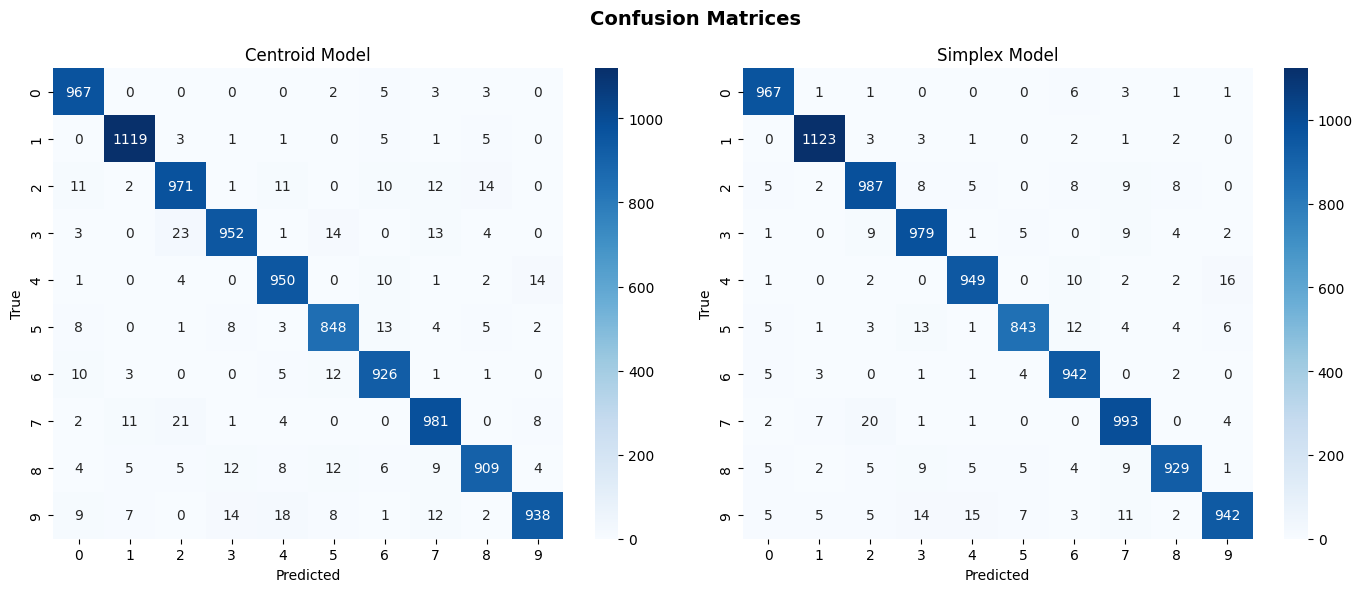

In [6]:
cm_centroid = confusion_matrix(true_labels, centroid_preds)
cm_simplex = confusion_matrix(true_labels, simplex_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cm, title in [
    (axes[0], cm_centroid, "Centroid Model"),
    (axes[1], cm_simplex, "Simplex Model"),
]:
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=range(10), yticklabels=range(10))
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

plt.suptitle("Confusion Matrices", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Per-Class Accuracy

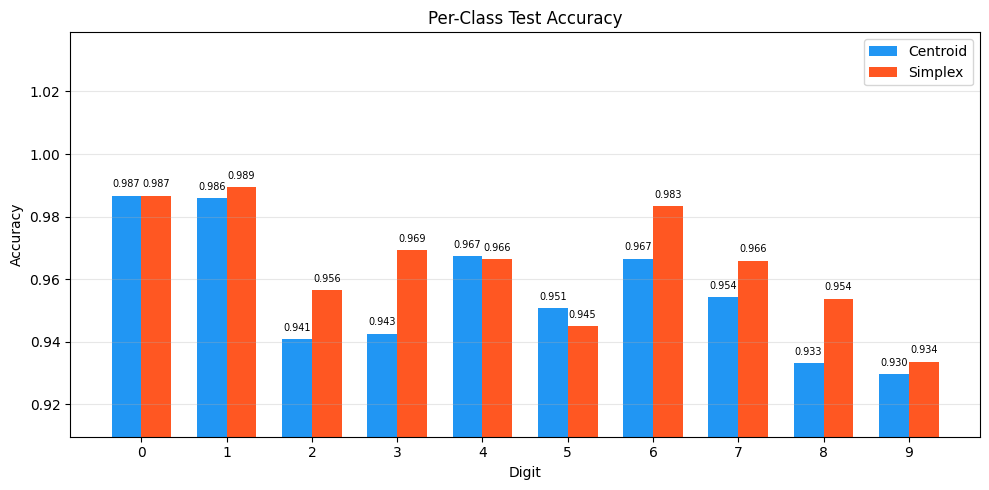

Digit   Centroid    Simplex       Diff
--------------------------------------
    0     0.9867     0.9867    +0.0000
    1     0.9859     0.9894    +0.0035
    2     0.9409     0.9564    +0.0155
    3     0.9426     0.9693    +0.0267
    4     0.9674     0.9664    -0.0010
    5     0.9507     0.9451    -0.0056
    6     0.9666     0.9833    +0.0167
    7     0.9543     0.9660    +0.0117
    8     0.9333     0.9538    +0.0205
    9     0.9296     0.9336    +0.0040


In [7]:
centroid_acc_per_class = []
simplex_acc_per_class = []
for c in range(10):
    mask = (true_labels == c)
    centroid_acc_per_class.append(centroid_correct[mask].mean())
    simplex_acc_per_class.append(simplex_correct[mask].mean())

x = np.arange(10)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, centroid_acc_per_class, width, label="Centroid", color="#2196F3")
bars2 = ax.bar(x + width/2, simplex_acc_per_class, width, label="Simplex", color="#FF5722")

ax.set_xlabel("Digit")
ax.set_ylabel("Accuracy")
ax.set_title("Per-Class Test Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(range(10))
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(bottom=min(min(centroid_acc_per_class), min(simplex_acc_per_class)) - 0.02)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.002, f"{h:.3f}",
                ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

# Print table
print(f"{'Digit':>5} {'Centroid':>10} {'Simplex':>10} {'Diff':>10}")
print("-" * 38)
for c in range(10):
    diff = simplex_acc_per_class[c] - centroid_acc_per_class[c]
    print(f"{c:>5d} {centroid_acc_per_class[c]:>10.4f} {simplex_acc_per_class[c]:>10.4f} {diff:>+10.4f}")

## 7. Misclassified Samples

Show the most confident errors for each model (highest confidence in the wrong class).

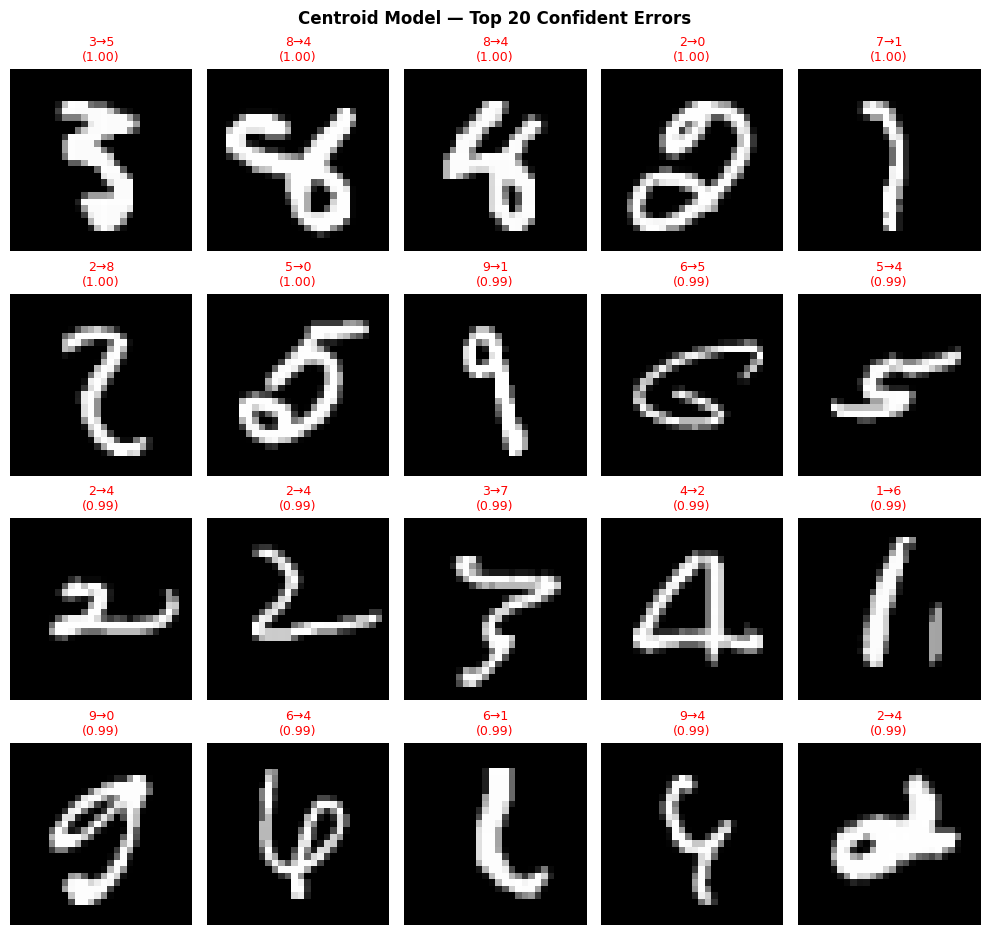

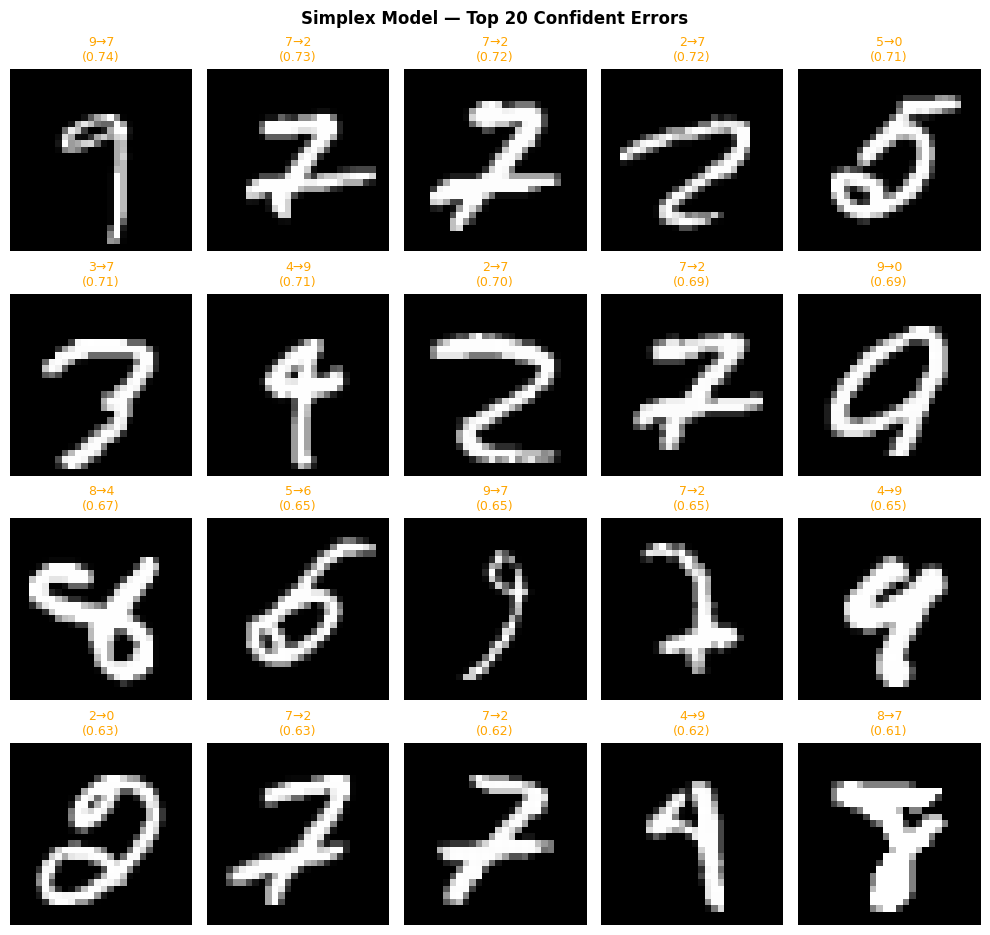

In [8]:
# Get raw test images for visualization (without normalization)
raw_transform = transforms.Compose([transforms.ToTensor()])
raw_test = datasets.MNIST(root=data_root, train=False, download=True, transform=raw_transform)
test_images = torch.stack([raw_test[i][0] for i in range(len(raw_test))])  # [10000, 1, 28, 28]


def plot_errors(preds, probs, title, n=20):
    """Plot the n most confident misclassifications."""
    wrong = np.where(preds != true_labels)[0]
    # Sort by confidence in wrong prediction (descending)
    confidences = probs[wrong, preds[wrong]]
    order = np.argsort(-confidences)
    worst = wrong[order[:n]]

    cols = 5
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.4))
    axes = axes.flatten()

    for i, idx in enumerate(worst):
        ax = axes[i]
        ax.imshow(test_images[idx].squeeze(), cmap="gray")
        conf = probs[idx, preds[idx]]
        ax.set_title(f"{true_labels[idx]}\u2192{preds[idx]}\n({conf:.2f})", fontsize=9,
                     color="red" if conf > 0.8 else "orange")
        ax.axis("off")

    for i in range(len(worst), len(axes)):
        axes[i].axis("off")

    fig.suptitle(f"{title} — Top {n} Confident Errors", fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_errors(centroid_preds, centroid_probs, "Centroid Model")
plot_errors(simplex_preds, simplex_probs, "Simplex Model")

## 8. Error Overlap Analysis

How much do the two models' errors overlap?

Centroid-only errors: 174
Simplex-only errors:  81
Both models wrong:    265
Total unique errors:  520
Both models correct:  9480


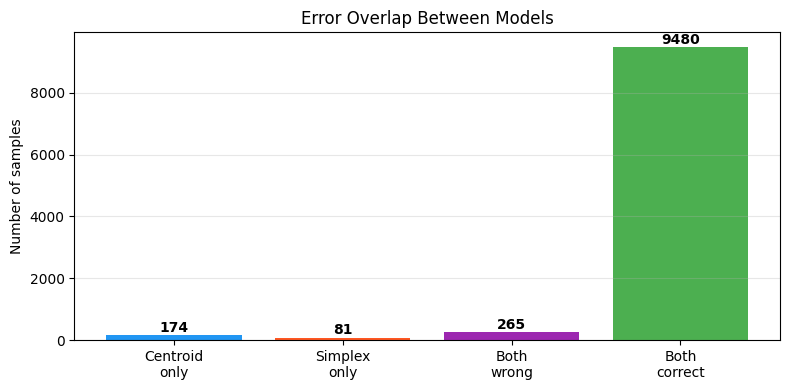


Shared errors by true digit:
  Digit 0: 10 shared errors
  Digit 1: 12 shared errors
  Digit 2: 34 shared errors
  Digit 3: 26 shared errors
  Digit 4: 24 shared errors
  Digit 5: 27 shared errors
  Digit 6: 14 shared errors
  Digit 7: 28 shared errors
  Digit 8: 37 shared errors
  Digit 9: 53 shared errors


In [9]:
centroid_errors = set(np.where(~centroid_correct)[0])
simplex_errors = set(np.where(~simplex_correct)[0])

only_centroid = centroid_errors - simplex_errors
only_simplex = simplex_errors - centroid_errors
both_wrong = centroid_errors & simplex_errors

print(f"Centroid-only errors: {len(only_centroid)}")
print(f"Simplex-only errors:  {len(only_simplex)}")
print(f"Both models wrong:    {len(both_wrong)}")
print(f"Total unique errors:  {len(centroid_errors | simplex_errors)}")
print(f"Both models correct:  {len(true_labels) - len(centroid_errors | simplex_errors)}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
categories = ["Centroid\nonly", "Simplex\nonly", "Both\nwrong", "Both\ncorrect"]
counts = [len(only_centroid), len(only_simplex), len(both_wrong),
          len(true_labels) - len(centroid_errors | simplex_errors)]
colors = ["#2196F3", "#FF5722", "#9C27B0", "#4CAF50"]

bars = ax.bar(categories, counts, color=colors)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            str(count), ha="center", va="bottom", fontweight="bold")

ax.set_ylabel("Number of samples")
ax.set_title("Error Overlap Between Models")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Per-class breakdown of shared errors
print(f"\nShared errors by true digit:")
both_wrong_arr = np.array(sorted(both_wrong))
if len(both_wrong_arr) > 0:
    for c in range(10):
        mask = true_labels[both_wrong_arr] == c
        n = mask.sum()
        if n > 0:
            print(f"  Digit {c}: {n} shared errors")

## 9. Hardest Samples

Visualize samples that both models get wrong — these are likely genuinely ambiguous or mislabeled.

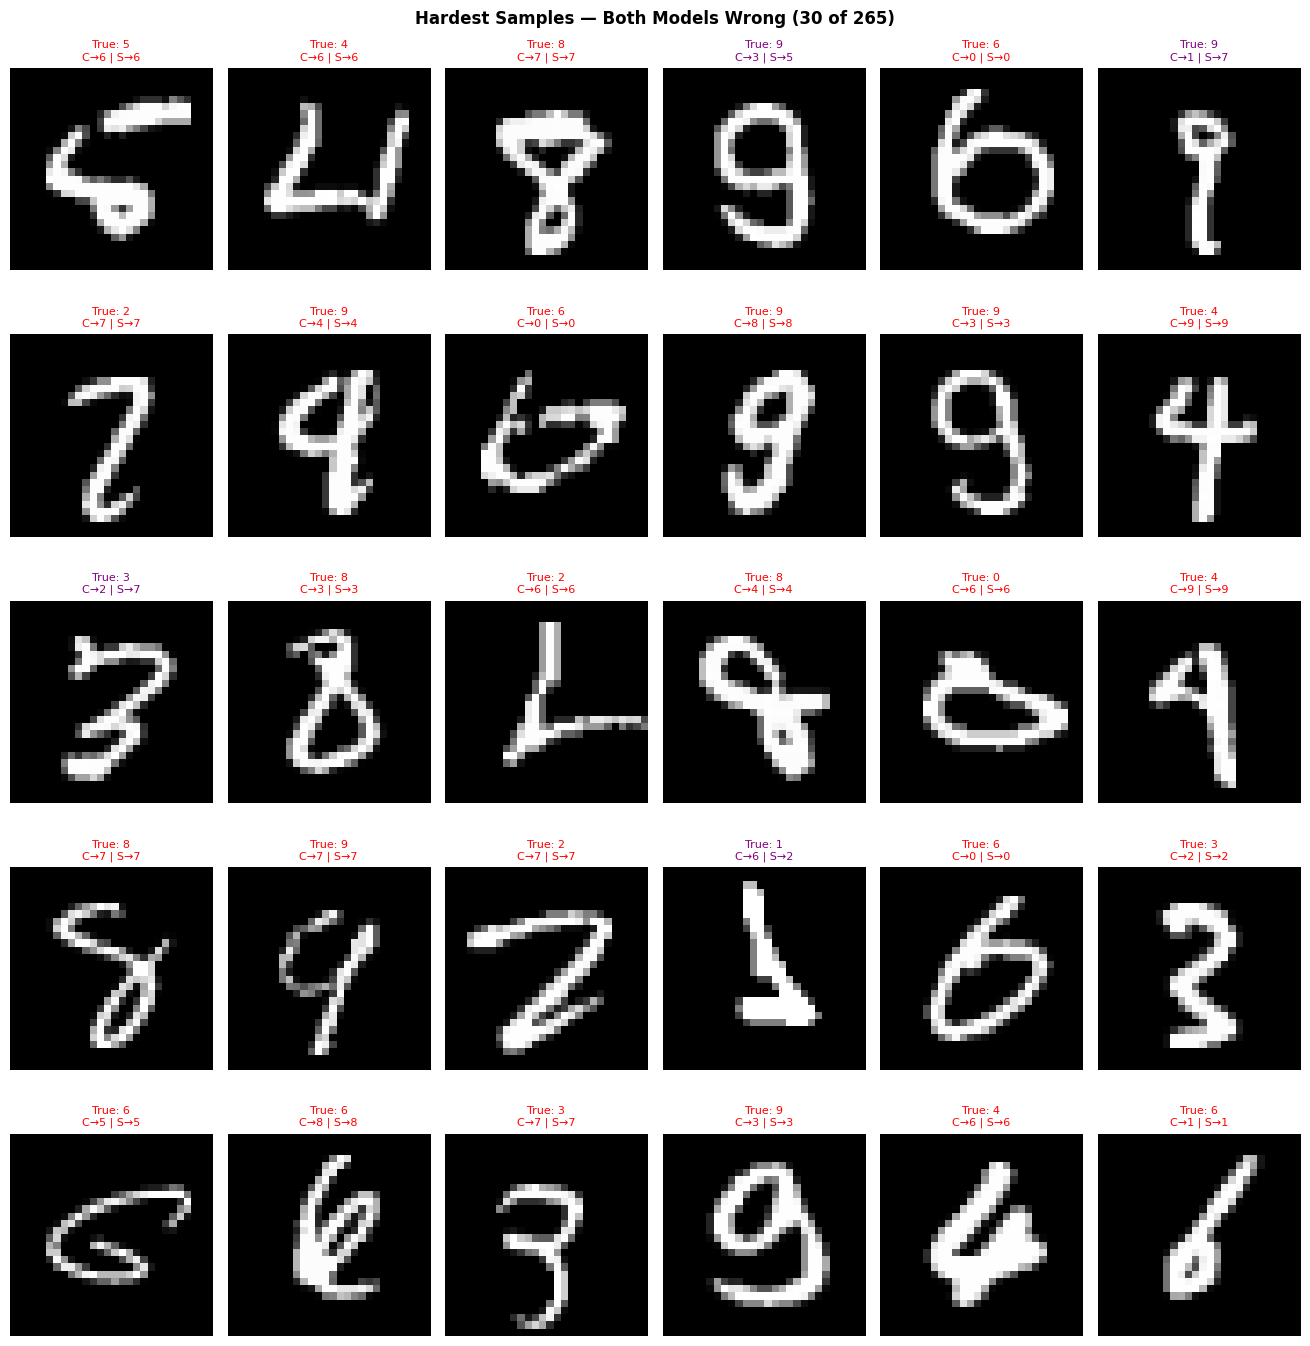


Both wrong AND same prediction: 221/265
Both wrong BUT different prediction: 44/265


In [10]:
both_wrong_list = sorted(both_wrong)
n_show = min(30, len(both_wrong_list))

if n_show == 0:
    print("No shared errors!")
else:
    cols = 6
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.8))
    axes = axes.flatten()

    for i, idx in enumerate(both_wrong_list[:n_show]):
        ax = axes[i]
        ax.imshow(test_images[idx].squeeze(), cmap="gray")
        true = true_labels[idx]
        cp = centroid_preds[idx]
        sp = simplex_preds[idx]
        ax.set_title(f"True: {true}\nC\u2192{cp} | S\u2192{sp}", fontsize=8,
                     color="red" if cp == sp else "purple")
        ax.axis("off")

    for i in range(n_show, len(axes)):
        axes[i].axis("off")

    fig.suptitle(f"Hardest Samples — Both Models Wrong ({n_show} of {len(both_wrong_list)})",
                 fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Do they agree on the wrong answer?
    agree_wrong = sum(1 for idx in both_wrong_list
                      if centroid_preds[idx] == simplex_preds[idx])
    print(f"\nBoth wrong AND same prediction: {agree_wrong}/{len(both_wrong_list)}")
    print(f"Both wrong BUT different prediction: {len(both_wrong_list) - agree_wrong}/{len(both_wrong_list)}")

## 10. Classification Reports

In [11]:
print("=" * 60)
print("CENTROID MODEL")
print("=" * 60)
print(classification_report(true_labels, centroid_preds, digits=4))

print("=" * 60)
print("SIMPLEX MODEL")
print("=" * 60)
print(classification_report(true_labels, simplex_preds, digits=4))

CENTROID MODEL
              precision    recall  f1-score   support

           0     0.9527    0.9867    0.9694       980
           1     0.9756    0.9859    0.9807      1135
           2     0.9446    0.9409    0.9427      1032
           3     0.9626    0.9426    0.9525      1010
           4     0.9491    0.9674    0.9581       982
           5     0.9464    0.9507    0.9485       892
           6     0.9488    0.9666    0.9576       958
           7     0.9460    0.9543    0.9501      1028
           8     0.9619    0.9333    0.9474       974
           9     0.9710    0.9296    0.9499      1009

    accuracy                         0.9561     10000
   macro avg     0.9559    0.9558    0.9557     10000
weighted avg     0.9562    0.9561    0.9560     10000

SIMPLEX MODEL
              precision    recall  f1-score   support

           0     0.9709    0.9867    0.9787       980
           1     0.9816    0.9894    0.9855      1135
           2     0.9536    0.9564    0.9550      